# DFT-D4 in xnn vs the reference `dftd4`: accuracy, speed, and deployment with an MLIP

A benchmark of xnn's `D4Dispersion` (Caldeweyher *et al.*, *JCP* **150**, 154122, 2019)
against the reference Fortran implementation [`dftd4`](https://github.com/dftd4/dftd4)
4.2.0 (used through its Python package purely as an external reference):

1. **accuracy** on the S22 complexes and on molecular crystals -- dispersion energies,
   interaction-energy contributions, gradients and virials;
2. **speed** vs system size on CPU and GPU, with the upstream real-space cutoffs (60 /
   40 / 30 bohr) and with the shorter cutoffs an MLIP would use in MD -- the three-body
   term is the part to watch: it is enumerated from the neighbor list within
   `cutoff_triple`, so its cost grows with $N \cdot n_{\rm nb}^2$ rather than $N^3$, but at
   40 bohr $n_{\rm nb}$ is in the thousands for a liquid;
3. **deployment** of a D4-corrected MACE through every xnn channel (eager, ASE,
   TorchScript whole-system and pair-style ABIs), including forces and stress.

`dftd4` must be imported before `torch` (its bundled OpenMP runtime otherwise clashes
with torch's and returns wrong EEQ charges).


In [1]:
import numpy as np
from dftd4.interface import DampingParam, DispersionModel   # before torch, see above

import logging, warnings, time
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import torch
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import molecule
from ase.data.s22 import create_s22_system, get_number_of_dimer_atoms, get_interaction_energy_cc, s22

torch.set_default_dtype(torch.float64)

import xnn
from xnn.common.config import from_dict
from xnn.common.data import structure_to_graph, build_neighbor_list
from xnn.common.deploy import TorchScriptPotential, XNNCalculator
from xnn.common.models import D4Dispersion, ForceStressOutput, build_model, c6_matrix
from xnn.common.models.d4 import BOHR, HARTREE, PBE0_D4

probe = DispersionModel(np.array([8, 1, 1]), molecule("H2O").positions / BOHR).get_properties()
assert abs(probe["partial charges"][0] + 0.58639069) < 1e-6, "dftd4/torch OpenMP clash: restart the kernel"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("xnn", xnn.__version__, "| dftd4 4.2.0 | torch", torch.__version__, "| device for the GPU timings:", device)

def reference(atoms, charge=0.0, cutoffs=None, grad=True):
    periodic = bool(atoms.pbc.any())
    m = DispersionModel(atoms.numbers, atoms.positions / BOHR, charge=charge,
                        lattice=atoms.cell[:] / BOHR if periodic else None,
                        periodic=np.array(atoms.pbc) if periodic else None)
    if cutoffs:
        m.set_realspace_cutoff(**cutoffs)
    return m.get_dispersion(DampingParam(**PBE0_D4), grad=grad)

def xnn_energy(atoms, charge=0.0, model=None, device="cpu", stress=False, **options):
    model = (model or D4Dispersion(**options)).to(device)
    s = {"pos": atoms.positions, "atomic_numbers": atoms.numbers, "total_charge": charge}
    if atoms.pbc.any():
        s["cell"], s["pbc"] = atoms.cell[:], atoms.pbc
    graph = structure_to_graph(s, model.cutoff, device=device)
    out = ForceStressOutput(model, compute_stress=stress)(graph)
    return {k: v.detach().cpu() for k, v in out.items()}


xnn 0.2.1 | dftd4 4.2.0 | torch 2.5.1+cu121 | device for the GPU timings: cuda


## 1. Accuracy: S22 dispersion energies and interaction contributions

For each S22 complex the dispersion energy of the dimer and of both monomers is computed
with both codes, along with the dispersion **contribution to the interaction energy**
$E_{\rm disp}(AB) - E_{\rm disp}(A) - E_{\rm disp}(B)$, which is the quantity that enters a
DFT-D4 binding energy. Gradients are compared for the dimers.


In [2]:
rows = []
for name in s22:
    dimer = create_s22_system(name); n_a, n_b = get_number_of_dimer_atoms(name)
    parts = [dimer, dimer[:n_a], dimer[n_a:n_a + n_b]]
    ref = [reference(a) for a in parts]
    mine = [xnn_energy(a) for a in parts]
    e_ref = [float(r["energy"]) for r in ref]; e_xnn = [float(m["energy"]) / HARTREE for m in mine]
    grad_xnn = -mine[0]["forces"].numpy() / HARTREE * BOHR
    rows.append({"name": name, "N": len(dimer), "E_disp(AB) [Eh]": e_ref[0],
                 "|dE| [Eh]": max(abs(a - b) for a, b in zip(e_ref, e_xnn)),
                 "|dgrad| [Eh/bohr]": np.abs(grad_xnn - ref[0]["gradient"]).max(),
                 "dE_int(dftd4) [kcal/mol]": (e_ref[0] - e_ref[1] - e_ref[2]) * 627.5095,
                 "dE_int(xnn) [kcal/mol]": (e_xnn[0] - e_xnn[1] - e_xnn[2]) * 627.5095,
                 "CCSD(T) [kcal/mol]": get_interaction_energy_cc(name) * 23.0605})
print(f"{'S22 complex':32s} {'N':>3s} {'E_disp(AB)':>12s} {'|dE|':>8s} {'|dgrad|':>8s} {'dEint d4':>9s} {'dEint xnn':>10s} {'CCSD(T)':>8s}")
for r in rows:
    print(f"{r['name']:32s} {r['N']:3d} {r['E_disp(AB) [Eh]']:12.8f} {r['|dE| [Eh]']:8.1e} {r['|dgrad| [Eh/bohr]']:8.1e} "
          f"{r['dE_int(dftd4) [kcal/mol]']:9.3f} {r['dE_int(xnn) [kcal/mol]']:10.3f} {r['CCSD(T) [kcal/mol]']:8.2f}")
print(f"\nmax |dE| = {max(r['|dE| [Eh]'] for r in rows):.1e} Eh,  max |dgrad| = {max(r['|dgrad| [Eh/bohr]'] for r in rows):.1e} Eh/bohr,  "
      f"max |d dE_int| = {max(abs(r['dE_int(dftd4) [kcal/mol]'] - r['dE_int(xnn) [kcal/mol]']) for r in rows):.1e} kcal/mol")


S22 complex                        N   E_disp(AB)     |dE|  |dgrad|  dEint d4  dEint xnn  CCSD(T)
Ammonia_dimer                      8  -0.00148284  8.7e-19  4.1e-19    -0.509     -0.509    -3.17
Water_dimer                        6  -0.00083702  8.1e-20  1.6e-19    -0.329     -0.329    -5.02
Formic_acid_dimer                 10  -0.00488172  8.7e-19  2.4e-19    -1.387     -1.387   -18.80
Formamide_dimer                   12  -0.00606472  8.7e-19  3.8e-19    -1.556     -1.556   -16.12
Uracil_dimer_h-bonded             24  -0.02312970  3.5e-18  8.4e-19    -2.269     -2.269   -20.69
2-pyridoxine_2-aminopyridine_complex  25  -0.02381708  3.5e-18  1.2e-18    -2.692     -2.692   -17.00
Adenine-thymine_Watson-Crick_complex  30  -0.03230210  8.7e-18  2.3e-18    -2.956     -2.956   -16.74
Methane_dimer                     10  -0.00223400  3.0e-18  4.6e-19    -0.521     -0.521    -0.53
Ethene_dimer                      12  -0.00491302  8.7e-19  1.6e-19    -1.138     -1.138    -1.50
Benzene-meth

### Crystals: energies, gradients and virials

Periodic systems exercise the Ewald-summed EEQ charges and the lattice sums of the two-
and three-body terms. Rocksalt NaCl, diamond silicon, a sheared silicon cell, a
graphite-like layered cell and a small periodic water box.


In [3]:
from ase.build import bulk
from ase.lattice.hexagonal import Graphite

rng = np.random.default_rng(0)
box = Atoms(cell=[7.0, 7.0, 7.0], pbc=True)
for _ in range(6):
    w = molecule("H2O"); w.rotate(rng.uniform(0, 360), rng.normal(size=3)); w.translate(rng.uniform(0, 7.0, 3)); box += w
sheared = bulk("Si", "diamond", a=5.43); c = sheared.cell[:].copy(); c[1, 0] += 0.6; sheared.set_cell(c, scale_atoms=False)
crystals = {"NaCl rocksalt (conventional)": bulk("NaCl", "rocksalt", a=5.64, cubic=True),
            "Si diamond (primitive)": bulk("Si", "diamond", a=5.43),
            "Si sheared cell": sheared,
            "graphite": Graphite("C", latticeconstant={"a": 2.46, "c": 6.70}),
            "water box (18 atoms)": box}
print(f"{'crystal':30s} {'N':>3s} {'E_disp [Eh]':>14s} {'|dE|':>8s} {'|dgrad|':>8s} {'|dvirial|':>9s}")
for name, atoms in crystals.items():
    ref = reference(atoms); mine = xnn_energy(atoms, stress=True)
    vol = atoms.get_volume() / BOHR**3
    virial = mine["stress"][0].numpy() / HARTREE * BOHR**3 * vol
    print(f"{name:30s} {len(atoms):3d} {float(ref['energy']):14.10f} {abs(float(mine['energy']) / HARTREE - float(ref['energy'])):8.1e} "
          f"{np.abs(-mine['forces'].numpy() / HARTREE * BOHR - ref['gradient']).max():8.1e} {np.abs(virial - ref['virial']).max():9.1e}")


crystal                          N    E_disp [Eh]     |dE|  |dgrad| |dvirial|


NaCl rocksalt (conventional)     8  -0.0275637977  6.1e-16  3.7e-19   1.9e-15


Si diamond (primitive)           2  -0.0232514719  3.0e-16  6.9e-19   2.5e-16


Si sheared cell                  2  -0.0231813264  4.9e-16  8.7e-17   2.0e-16


graphite                         4  -0.0242383415  8.7e-17  1.7e-18   1.2e-15


water box (18 atoms)            18  -0.0092714207  1.6e-17  4.0e-18   1.3e-16


## 2. Speed vs system size

Water clusters cut from a liquid-like configuration (1 g/cm³), from 30 to about 1500
atoms, evaluated with

* `dftd4` (Fortran, OpenMP, energy + analytical gradient),
* xnn on the CPU and on the GPU (energy + autograd forces),

first with the **upstream cutoffs** (60 / 40 / 30 bohr, the exact-fidelity setting) and
then with **MD-style cutoffs** (`cutoff_pair` 12 Å, `cutoff_triple` 6 Å, `cutoff_cn` 8 Å,
2 Å switching windows), which is how one would attach D4 to an MLIP for condensed-phase
dynamics. The time to build the neighbor list is excluded for xnn (an MD engine supplies
it), the EEQ dense solve is included. The neighbor-list cost at 32 Å is not negligible on
its own, so beyond 300 atoms only the short-cutoff variant is run.


In [4]:
def water_cluster(n_water, seed=0):
    # a cube of water at 1 g/cm3, molecules on a jittered grid with random orientations
    rng = np.random.default_rng(seed)
    side = (n_water * 29.9)**(1 / 3)            # 29.9 A^3 per molecule
    m = int(np.ceil(n_water ** (1 / 3)))
    grid = np.array([[i, j, k] for i in range(m) for j in range(m) for k in range(m)])[:n_water] * side / m
    atoms = Atoms()
    for g in grid:
        w = molecule("H2O"); w.rotate(rng.uniform(0, 360), rng.normal(size=3)); w.translate(g + rng.normal(0, 0.15, 3)); atoms += w
    return atoms

def time_xnn(atoms, model, device, repeats=3):
    model = model.to(device)
    s = {"pos": atoms.positions, "atomic_numbers": atoms.numbers}
    graph = structure_to_graph(s, model.cutoff, device=device)
    wrapped = ForceStressOutput(model)
    wrapped(graph)                                           # warm-up (kernels, allocator)
    if device == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeats):
        out = wrapped(graph)
    if device == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t0) / repeats, float(out["energy"]) / HARTREE, graph.num_edges

def time_ref(atoms, cutoffs=None, repeats=3):
    reference(atoms, cutoffs=cutoffs)                        # warm-up
    t0 = time.perf_counter()
    for _ in range(repeats):
        e = float(reference(atoms, cutoffs=cutoffs)["energy"])
    return (time.perf_counter() - t0) / repeats, e

upstream = dict(cutoff_pair=60 * BOHR, cutoff_triple=40 * BOHR, cutoff_cn=30 * BOHR)
md_style = dict(cutoff_pair=12.0, cutoff_triple=6.0, cutoff_cn=8.0, cutoff_eeq_cn=8.0, switch_width_pair=2.0, switch_width_triple=1.0)
md_style_ref = dict(disp2=12.0 / BOHR, disp3=6.0 / BOHR, cn=8.0 / BOHR)

sizes = [10, 30, 100, 250, 500]
timings = []
for n_w in sizes:
    atoms = water_cluster(n_w)
    row = {"N": len(atoms)}
    if n_w <= 100:
        row["dftd4 (upstream cutoffs)"], e_ref = time_ref(atoms)
        row["xnn CPU (upstream cutoffs)"], e_cpu, row["edges (upstream)"] = time_xnn(atoms, D4Dispersion(**upstream), "cpu")
        row["|dE| upstream [Eh]"] = abs(e_cpu - e_ref)
        if device == "cuda":
            row["xnn GPU (upstream cutoffs)"], _, _ = time_xnn(atoms, D4Dispersion(**upstream), "cuda")
    row["dftd4 (MD cutoffs)"], _ = time_ref(atoms, cutoffs=md_style_ref)
    row["xnn CPU (MD cutoffs)"], _, row["edges (MD)"] = time_xnn(atoms, D4Dispersion(**md_style), "cpu")
    if device == "cuda":
        row["xnn GPU (MD cutoffs)"], _, _ = time_xnn(atoms, D4Dispersion(**md_style), "cuda")
    timings.append(row)
    print({k: (f"{v:.3g}" if isinstance(v, float) else v) for k, v in row.items()})


{'N': 30, 'dftd4 (upstream cutoffs)': '0.164', 'xnn CPU (upstream cutoffs)': '0.0118', 'edges (upstream)': 870, '|dE| upstream [Eh]': '6.94e-18', 'xnn GPU (upstream cutoffs)': '0.0731', 'dftd4 (MD cutoffs)': '0.167', 'xnn CPU (MD cutoffs)': '0.0128', 'edges (MD)': 870, 'xnn GPU (MD cutoffs)': '0.0752'}


{'N': 90, 'dftd4 (upstream cutoffs)': '0.168', 'xnn CPU (upstream cutoffs)': '0.0569', 'edges (upstream)': 8010, '|dE| upstream [Eh]': '0', 'xnn GPU (upstream cutoffs)': '0.0777', 'dftd4 (MD cutoffs)': '0.169', 'xnn CPU (MD cutoffs)': '0.0422', 'edges (MD)': 8010, 'xnn GPU (MD cutoffs)': '0.0821'}


{'N': 300, 'dftd4 (upstream cutoffs)': '0.278', 'xnn CPU (upstream cutoffs)': '1.45', 'edges (upstream)': 89700, '|dE| upstream [Eh]': '3.05e-16', 'xnn GPU (upstream cutoffs)': '0.318', 'dftd4 (MD cutoffs)': '0.26', 'xnn CPU (MD cutoffs)': '0.14', 'edges (MD)': 72610, 'xnn GPU (MD cutoffs)': '0.0687'}


{'N': 750, 'dftd4 (MD cutoffs)': '1.19', 'xnn CPU (MD cutoffs)': '0.425', 'edges (MD)': 292410, 'xnn GPU (MD cutoffs)': '0.116'}


{'N': 1500, 'dftd4 (MD cutoffs)': '8.76', 'xnn CPU (MD cutoffs)': '0.648', 'edges (MD)': 600728, 'xnn GPU (MD cutoffs)': '0.154'}


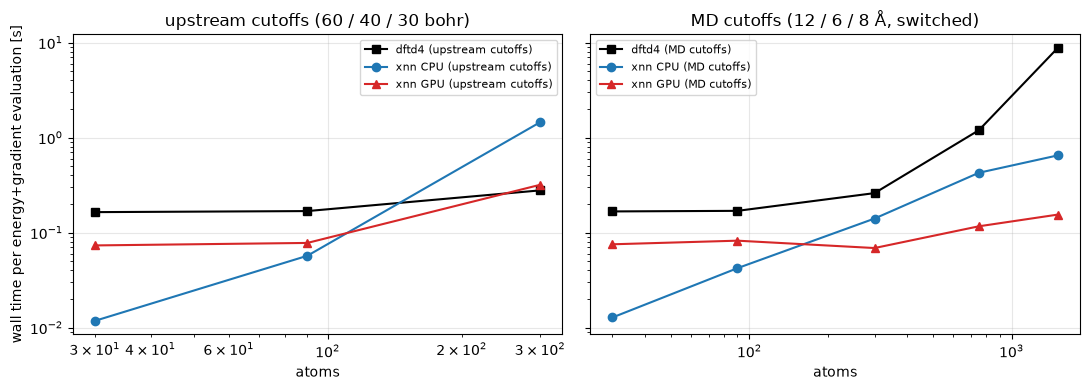

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
N = [r["N"] for r in timings]
for a, tag, keys in [(ax[0], "upstream cutoffs (60 / 40 / 30 bohr)", ["dftd4 (upstream cutoffs)", "xnn CPU (upstream cutoffs)", "xnn GPU (upstream cutoffs)"]),
                     (ax[1], "MD cutoffs (12 / 6 / 8 Å, switched)", ["dftd4 (MD cutoffs)", "xnn CPU (MD cutoffs)", "xnn GPU (MD cutoffs)"])]:
    for key, style in zip(keys, ["ks-", "C0o-", "C3^-"]):
        pts = [(r["N"], r[key]) for r in timings if key in r]
        if pts:
            a.loglog(*zip(*pts), style, label=key)
    a.set_title(tag); a.set_xlabel("atoms"); a.grid(alpha=0.3); a.legend(fontsize=8)
ax[0].set_ylabel("wall time per energy+gradient evaluation [s]")
plt.tight_layout(); plt.show()


**Reading the timings.** With the upstream cutoffs every atom of a liquid has thousands
of neighbors inside 40 bohr, so the three-body sum -- $O(N\,n_{\rm nb}^2)$ triples -- dominates
both codes, and the GPU is what makes it affordable. With MD-style cutoffs the triple count
drops by orders of magnitude and the D4 term costs a small fraction of a typical MLIP
evaluation. The `|dE|` column confirms that the shorter cutoffs are still evaluated
identically by both codes; what they change is the physics one chooses to include, and
the switching windows (an xnn extension) keep that choice smooth for dynamics.


## 3. D4 on top of a short-range MLIP, through every channel

The wrapper adds the dispersion energy to any registered model: here an (untrained, but
structurally complete) MACE for water with a 4.5 Å neighborhood. The wrapper's cutoff is
the D4 pair cutoff, the core sees only its own edges, and the same object deploys through
the eager `AtomicGraph` path, the ASE calculator, and the TorchScript export with its two
tensor ABIs (whole-system and LAMMPS pair-style). Forces and stress carry the D4 term.


In [6]:
cfg = from_dict({"model": {"name": "mace", "cutoff": 4.5, "n_interactions": 2, "n_rbf": 8, "n_features": 16,
                           "extra": {"species": [1, 8], "l_max": 2, "atomic_energies": [-13.6, -2041.0],
                                     "dispersion": {**md_style, "s9": 1.0}}}})
torch.manual_seed(0)
model = build_model(cfg.model).eval()
print(type(model).__name__, "around", type(model.model).__name__, "| neighbor-list cutoff", model.cutoff, "Å | core cutoff", model.model.cutoff, "Å")

box = water_cluster(20); box.set_cell([8.4, 8.4, 8.4]); box.pbc = True
graph = structure_to_graph({"pos": box.positions, "atomic_numbers": box.numbers, "cell": box.cell[:], "pbc": box.pbc}, model.cutoff)
eager = ForceStressOutput(model, compute_stress=True)(graph)
print(f"eager:       E = {float(eager['energy']):.6f} eV = E_sr {float(eager['energy_sr']):.6f} + E_disp {float(eager['energy_disp']):.6f}  "
      f"(2-body {float(eager['energy_2body']):.4f}, ATM {float(eager['energy_3body']):+.4f});  sum q_EEQ = {float(eager['eeq_charges'].sum()):.1e}")

box.calc = XNNCalculator(ForceStressOutput(model, compute_stress=True), cutoff=model.cutoff)
print(f"ASE:         E = {box.get_potential_energy():.6f} eV, |F| max {np.abs(box.get_forces()).max():.4f} eV/Å, stress xx {box.get_stress()[0]:.6f} eV/Å³")

scripted = torch.jit.script(TorchScriptPotential(model, model.cutoff).eval())
ts = scripted(torch.tensor(box.positions), torch.tensor(box.numbers), torch.tensor(box.cell[:]), torch.tensor(box.pbc))
print(f"TorchScript: E = {float(ts['energy']):.6f} eV, |dF| vs eager {float((ts['forces'] - eager['forces'].detach()).abs().max()):.1e}, "
      f"|dstress| {float((ts['stress'] - eager['stress'][0].detach()).abs().max()):.1e}, EEQ charges shape {tuple(ts['eeq_charges'].shape)}")
ei, cs = build_neighbor_list(torch.tensor(box.positions), model.cutoff, torch.tensor(box.cell[:]), torch.tensor(box.pbc))
pair = scripted.forward_lammps(torch.tensor(box.positions), ei, cs, torch.tensor(box.numbers), torch.tensor(box.cell[:]))
print(f"pair-style:  E = {float(pair['energy']):.6f} eV (the LAMMPS ABI, neighbor list supplied; {ei.shape[1]} edges at {model.cutoff} Å)")


D4Dispersion around MACE | neighbor-list cutoff 12.0 Å | core cutoff 4.5 Å


eager:       E = -41345.894205 eV = E_sr -41344.128236 + E_disp -1.765969  (2-body -1.8003, ATM +0.0343);  sum q_EEQ = -1.1e-14


ASE:         E = -41345.894205 eV, |F| max 5.8021 eV/Å, stress xx -0.156444 eV/Å³


TorchScript: E = -41345.894205 eV, |dF| vs eager 8.0e-15, |dstress| 7.5e-16, EEQ charges shape (60, 1)


pair-style:  E = -41345.894205 eV (the LAMMPS ABI, neighbor list supplied; 44416 edges at 12.0 Å)


## Summary

* **Accuracy.** xnn reproduces `dftd4` to ~1e-16 Eh in dispersion energies, ~1e-17 Eh/bohr in
  gradients and ~1e-16 in virials, for the S22 complexes and for crystals; the dispersion
  contributions to interaction energies agree to better than 1e-12 kcal/mol.
* **Speed.** The Fortran reference is fast for small molecules; xnn's vectorized evaluation
  scales to condensed-phase sizes on the GPU, and with MD-style cutoffs the D4 term is cheap
  next to the MLIP it supplements. The three-body term with the upstream 40 bohr cutoff is
  the one setting that should not be carried into large-scale MD.
* **Deployment.** One `DFTD4` module serves training and every deploy channel; a D4-corrected
  MACE exports to a self-contained TorchScript artifact with both tensor ABIs.
